# Ecartul de gen

**95 din 100 de români onorați pe străzi sunt bărbați.**

Sursa electorală conține ~105.000 de adrese în 41 de județe. Clasificând persoanele onorate după gen, obținem o imagine a memoriei colective: pe cine consideră comunitățile demn de o placă de stradă.

Sursa: Registrul Secțiilor de Vot, 14.05.2025 · Clasificare: curation manual + LLM batch

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'font.family': 'serif',
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
ACCENT = '#C04F35'
INK    = '#15171A'
MUTED  = '#6E6E70'

conn = sqlite3.connect('../data/streets.db')
conn.row_factory = sqlite3.Row
print('Connected.')

Connected.


## 1. Raportul de gen la nivel național

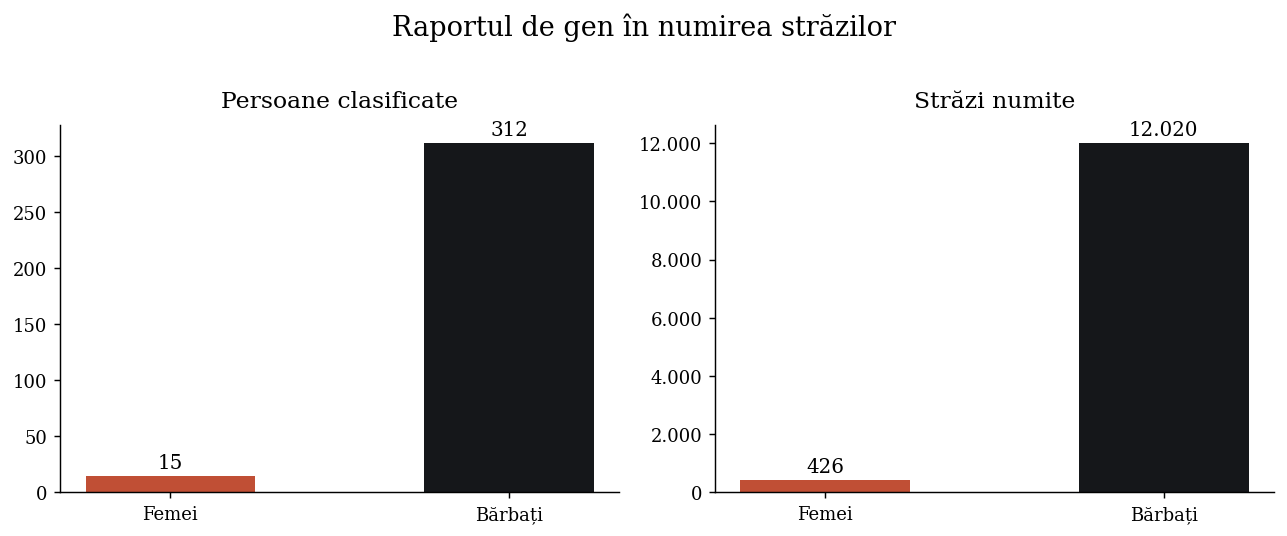

Femei: 4.6% din persoanele clasificate


In [2]:
df_ratio = pd.read_sql("""
    SELECT p.gender, COUNT(DISTINCT p.core_name_norm) AS persons,
           COUNT(*) AS streets
    FROM electoral_dedup sd
    JOIN persons p ON p.core_name_norm = sd.core_name_norm
    WHERE p.gender IN ('M','F')
    GROUP BY p.gender
""", conn)

total_persons = df_ratio['persons'].sum()
total_streets = df_ratio['streets'].sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title in zip(axes, ['persons','streets'], ['Persoane clasificate','Străzi numite']):
    colors = [INK if g == 'M' else ACCENT for g in df_ratio['gender']]
    bars = ax.bar(df_ratio['gender'].map({'M':'Bărbați','F':'Femei'}), df_ratio[col], color=colors, width=0.5)
    for bar, val in zip(bars, df_ratio[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + df_ratio[col].max()*0.01,
                f'{val:,}'.replace(',','.'), ha='center', va='bottom', fontsize=11)
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_ylabel('')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'.replace(',','.')))

fig.suptitle('Raportul de gen în numirea străzilor', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

f_pct = df_ratio.loc[df_ratio.gender=='F','persons'].values[0] / total_persons * 100
print(f'Femei: {f_pct:.1f}% din persoanele clasificate')

## 2. Top femei vs. top bărbați

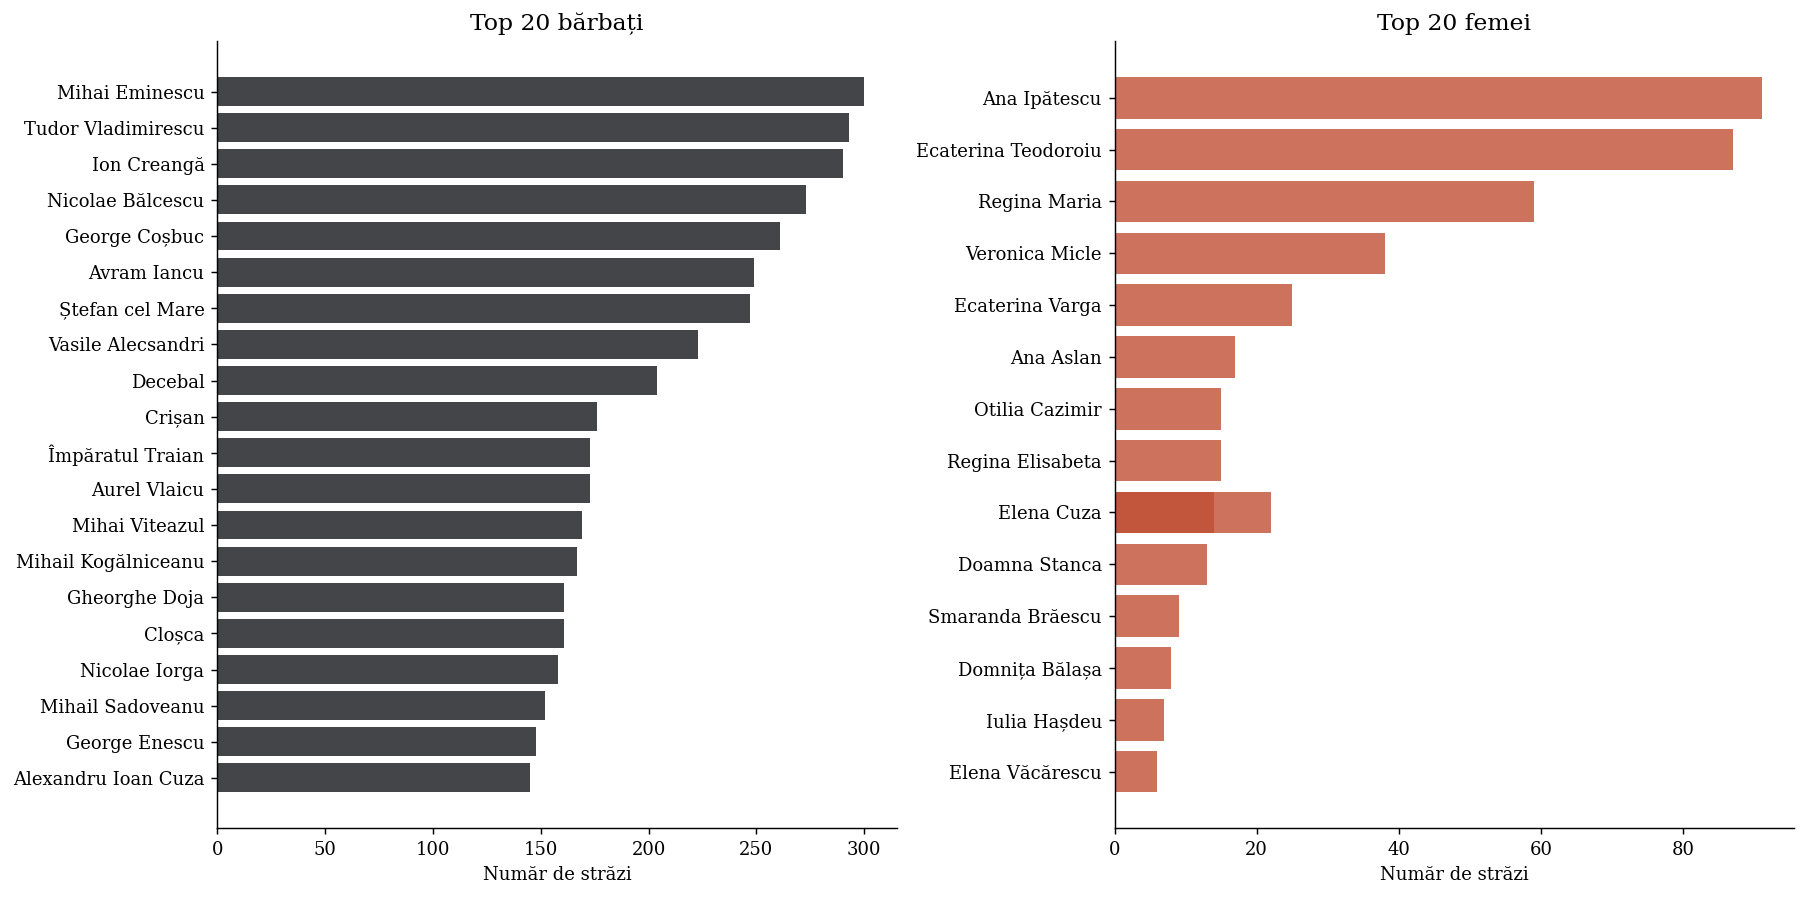

Cel mai onorat bărbat: Mihai Eminescu (300 străzi)
Cea mai onorată femeie: Ana Ipătescu (91 străzi)
Raport: x3.3 mai multe străzi


In [3]:
df_top = pd.read_sql("""
    SELECT p.full_name, p.gender, p.profession, p.era, COUNT(*) AS streets
    FROM electoral_dedup sd
    JOIN persons p ON p.core_name_norm = sd.core_name_norm
    WHERE p.gender IN ('M','F')
    GROUP BY p.core_name_norm
    ORDER BY streets DESC
""", conn)

top_m = df_top[df_top.gender=='M'].head(20)
top_f = df_top[df_top.gender=='F'].head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, df, color, title in [
    (axes[0], top_m, INK, 'Top 20 bărbați'),
    (axes[1], top_f, ACCENT, 'Top 20 femei'),
]:
    ax.barh(df['full_name'][::-1], df['streets'][::-1], color=color, alpha=0.8)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Număr de străzi')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'.replace(',','.')))

# Note: x-axes differ — scale gap is itself the story
plt.tight_layout()
plt.show()

print(f'Cel mai onorat bărbat: {top_m.iloc[0].full_name} ({top_m.iloc[0].streets} străzi)')
print(f'Cea mai onorată femeie: {top_f.iloc[0].full_name} ({top_f.iloc[0].streets} străzi)')
print(f'Raport: x{top_m.iloc[0].streets / top_f.iloc[0].streets:.1f} mai multe străzi')

## 3. Ecartul pe județe

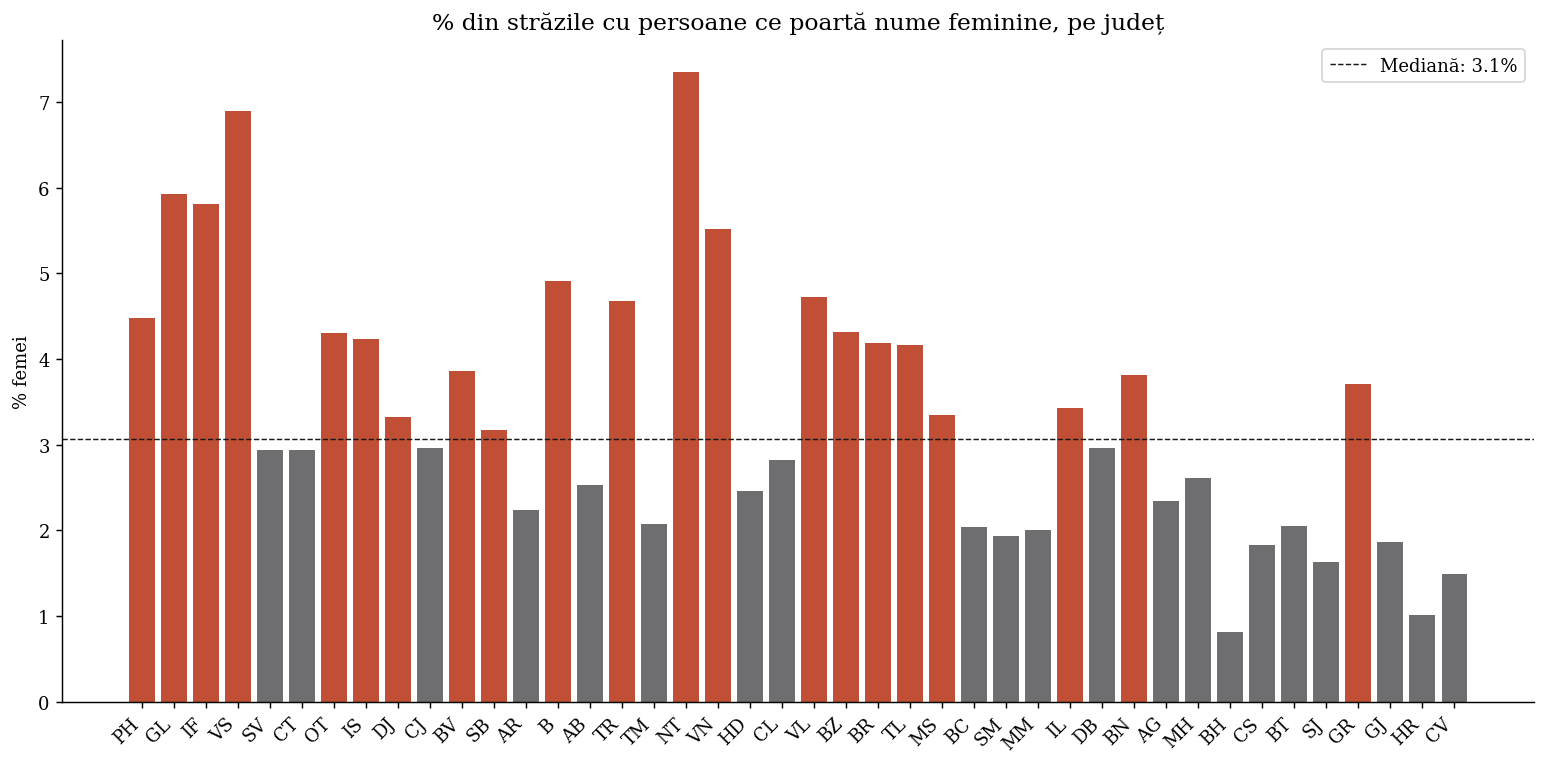

In [4]:
df_judet = pd.read_sql("""
    SELECT sd.judet,
           SUM(CASE WHEN p.gender='F' THEN 1 ELSE 0 END) AS f_streets,
           SUM(CASE WHEN p.gender='M' THEN 1 ELSE 0 END) AS m_streets,
           COUNT(*) AS total_person_streets
    FROM electoral_dedup sd
    JOIN persons p ON p.core_name_norm = sd.core_name_norm
    WHERE p.gender IN ('M','F')
    GROUP BY sd.judet
    HAVING total_person_streets >= 10
    ORDER BY f_streets DESC
""", conn)

df_judet['f_pct'] = df_judet['f_streets'] / df_judet['total_person_streets'] * 100

fig, ax = plt.subplots(figsize=(12, 6))
colors = [ACCENT if p > df_judet['f_pct'].median() else MUTED for p in df_judet['f_pct']]
ax.bar(df_judet['judet'], df_judet['f_pct'], color=colors)
ax.axhline(df_judet['f_pct'].median(), color=INK, linestyle='--', linewidth=0.8, label=f'Mediană: {df_judet["f_pct"].median():.1f}%')
ax.set_title('% din străzile cu persoane ce poartă nume feminine, pe județ', fontsize=13)
ax.set_ylabel('% femei')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Ecartul pe epoci — se îngustează în timp?

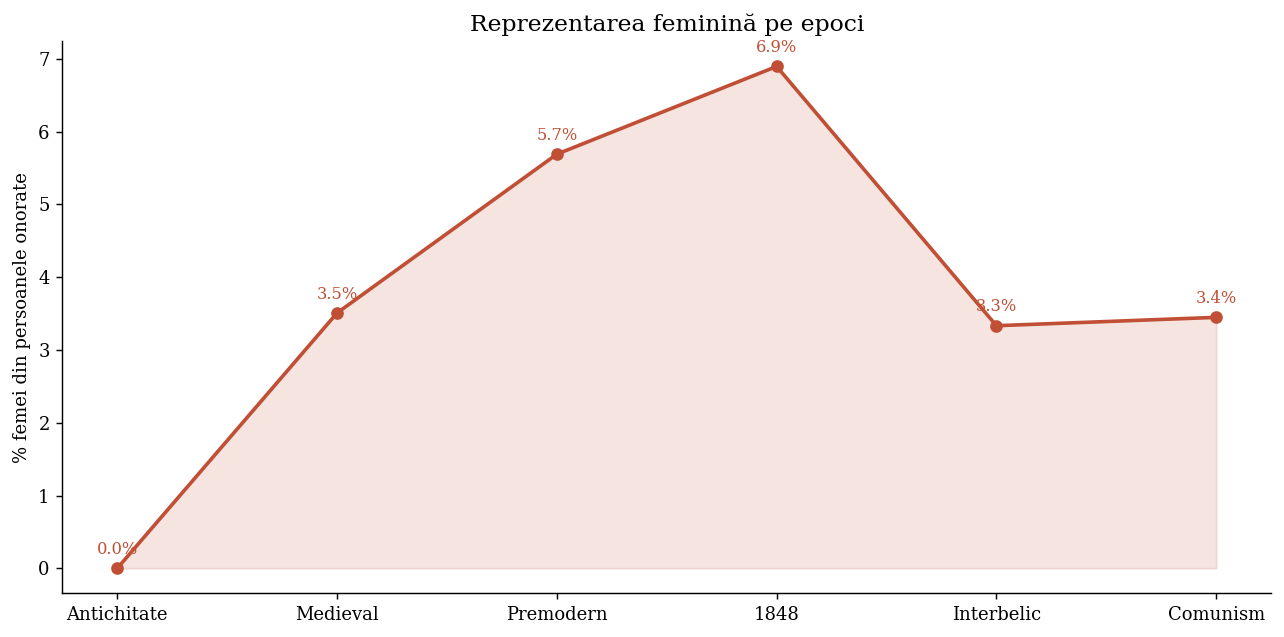

In [5]:
ERA_ORDER = ['ancient','medieval','premodern','1848','interwar','communist']
ERA_RO = {
    'ancient':'Antichitate','medieval':'Medieval','premodern':'Premodern',
    '1848':'1848','interwar':'Interbelic','communist':'Comunism'
}

df_era = pd.read_sql("""
    SELECT p.era, p.gender, COUNT(DISTINCT p.core_name_norm) AS persons
    FROM persons p
    WHERE p.gender IN ('M','F') AND p.era IS NOT NULL
    GROUP BY p.era, p.gender
""", conn)

df_era_pivot = df_era.pivot(index='era', columns='gender', values='persons').fillna(0)
df_era_pivot = df_era_pivot.reindex([e for e in ERA_ORDER if e in df_era_pivot.index])
df_era_pivot.index = [ERA_RO.get(e, e) for e in df_era_pivot.index]
df_era_pivot['f_pct'] = df_era_pivot['F'] / (df_era_pivot['M'] + df_era_pivot['F']) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_era_pivot.index, df_era_pivot['f_pct'], marker='o', color=ACCENT, linewidth=2)
ax.fill_between(df_era_pivot.index, df_era_pivot['f_pct'], alpha=0.15, color=ACCENT)
ax.set_ylabel('% femei din persoanele onorate')
ax.set_title('Reprezentarea feminină pe epoci', fontsize=13)
for i, (era, row) in enumerate(df_era_pivot.iterrows()):
    ax.annotate(f"{row['f_pct']:.1f}%", (i, row['f_pct']), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9, color=ACCENT)
plt.tight_layout()
plt.show()

In [6]:
conn.close()